# Vol.04: リードラグ分析（Lead-Lag Analysis）
**暗号資産データ分析入門シリーズ**

---

**テーマ**: 銘柄間の「先行・遅行」関係を定量的に検証する

### 「同時に動く」の先にあるもの

Vol.03 では、BTC・ETH・SOLが強い正の相関を持つことを確認しました。しかし、これは「同じ瞬間に同じ方向に動く」という事実を示しているにすぎません。

実際の市場では、もう一つ重要な問いがあります。**「どちらが先に動くのか？」**

BTCが急落した翌日にETHが追随して下がる。あるいは、ETHの出来高が急増した翌日にSOLも動き出す。こうした「時間差を伴う関係」は、同時点の相関分析では検出できません。ラグ=0の相関がいくら高くても、「BTCが先に動いてETHが追随する」のか「両者が全く同時に動く」のかは区別できないのです。

### なぜ「先に動く銘柄」を知ることが重要なのか

先行・遅行関係を定量的に把握できれば、それは直接的なトレーディングの仮説になります。

「BTCが大きく動いた翌日に、ETHが同じ方向に動く傾向がある」— もしこれが統計的に確認できるなら、BTCの動きを**シグナル**としてETHのポジションを取る、という戦略が考えられます。これはVol.07以降で学ぶ「シグナル → ポジション → 損益」の流れに直結する、実戦的な仮説です。

ただし、ここには重大な落とし穴があります。リードラグ関係は**安定しているとは限りません**。ある月には明確だった先行関係が、翌月には消えている、あるいは逆転している可能性があります。「見つかった関係が本当に使えるのか」を複数の角度から検証することが不可欠です。

### このnotebookで確かめること

1. BTC・ETH・SOL間に、日足レベルで**先行・遅行関係は存在するか？**
2. もし存在するなら、それは**統計的に有意か？** 期間を通じて**安定しているか？**
3. その関係をシグナルとして利用した場合、**実際に利益を生むか？** 取引コストを差し引いても成り立つか？

### このnotebookで学ぶこと

1. **ラグ付き相関係数** — 時間をずらして相関を計算する方法
2. **クロスコリログラム** — ラグ相関を可視化して先行・遅行関係を読み取る
3. **リードラグの安定性** — 期間を分割して一貫性を確認
4. **トレーディングシミュレーション** — リードラグを利用した戦略の損益を検証

## 1. 環境準備

In [1]:
!pip install requests pandas numpy matplotlib japanize-matplotlib scipy -q

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
import time

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print("ライブラリの読み込み完了")

ライブラリの読み込み完了


## 2. データ取得

BTC・ETH・SOLの**日足**データを取得します。

リードラグ分析は短い時間足（5分足など）で行われることもありますが、ここでは日足を使います。
日足なら直感的に「昨日のBTCの動き → 今日のETHの動き」として解釈でき、
また十分なサンプル数（3年分 = 約1,095本）が確保できます。

In [3]:
BINANCE_API_URL = "https://api.binance.com/api/v3/klines"

def fetch_ohlcv(symbol, interval, start_date, end_date, limit=1000):
    """
    Binance REST API から OHLCV データを取得する。

    Parameters
    ----------
    symbol : str     — 銘柄（例: 'BTCUSDT'）
    interval : str   — 時間足（例: '1h', '5m', '1d'）
    start_date : str — 開始日（例: '2024-01-01'）
    end_date : str   — 終了日（例: '2025-01-01'）※この日は含まない
    limit : int      — 1回のリクエストあたりの取得本数（最大1000）

    Returns
    -------
    pd.DataFrame — columns: [open, high, low, close, volume], index: timestamp (UTC)
    """
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)

    all_data = []
    current_ts = start_ts

    while current_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ts,
            "endTime": end_ts - 1,
            "limit": limit,
        }
        resp = requests.get(BINANCE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data.extend(data)
        current_ts = data[-1][0] + 1
        time.sleep(0.2)

    if not all_data:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_close_time", "_quote_vol", "_trades", "_taker_buy_vol",
        "_taker_buy_quote", "_ignore",
    ])

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# BTC・ETH・SOLの日足データを取得（3年間）
symbols = {"BTC": "BTCUSDT", "ETH": "ETHUSDT", "SOL": "SOLUSDT"}
since_date = "2022-01-01"
until_date = "2025-01-01"

data_1d = {}
for name, sym in symbols.items():
    print(f"取得中: {name} (1d)...", end=" ")
    data_1d[name] = fetch_ohlcv(sym, "1d", since_date, until_date)
    print(f"{len(data_1d[name]):,} 本")

# リターンのDataFrameを作成
returns_1d = pd.DataFrame({
    name: data_1d[name]["close"].pct_change()
    for name in symbols
}).dropna()

print(f"\nリターンデータ: {len(returns_1d)} 日")
print(f"期間: {returns_1d.index[0].date()} 〜 {returns_1d.index[-1].date()}")
print()
print("=== 同時点の相関（参考）===")
display(returns_1d.corr().round(4))

取得中: BTC (1d)... 

1,096 本
取得中: ETH (1d)... 

1,096 本
取得中: SOL (1d)... 

1,096 本

リターンデータ: 1095 日
期間: 2022-01-02 〜 2024-12-31

=== 同時点の相関（参考）===


,BTC,ETH,SOL
BTC,1.0000,0.8468,0.7263
ETH,0.8468,1.0000,0.7260
SOL,0.7263,0.7260,1.0000


## 3. ラグ付き相関係数の計算

### ラグ付き相関とは

通常の相関は、同じ時点のデータ同士を比較します。
**ラグ付き相関**では、一方の時系列を時間方向にずらして相関を計算します。

具体的には、BTC のリターン $r_{\text{BTC}}(t)$ と ETH のリターン $r_{\text{ETH}}(t + k)$ の相関を、
ラグ $k$ を変えながら計算します。

- **$k > 0$（正のラグ）**: BTCが**先行**してETHが**遅行**する関係を検出
- **$k < 0$（負のラグ）**: ETHが**先行**してBTCが**遅行**する関係を検出
- **$k = 0$**: 同時点の相関（通常の相関係数）

もし「BTCが上がった翌日にETHも上がる」なら、**lag=+1 で相関が高くなる**はずです。

In [4]:
def compute_lag_correlation(series_x, series_y, max_lag=5):
    """
    series_x と series_y のラグ付き相関を計算する。

    lag=k のとき: corr(series_x[t], series_y[t+k]) を計算する。
    → lag>0 は series_x が先行、series_y が遅行する関係を検出。
    """
    lags = list(range(-max_lag, max_lag + 1))
    correlations = []
    p_values = []

    for lag in lags:
        if lag > 0:
            x = series_x.iloc[:-lag]
            y = series_y.iloc[lag:]
        elif lag < 0:
            x = series_x.iloc[-lag:]
            y = series_y.iloc[:lag]
        else:
            x = series_x
            y = series_y

        # 共通のインデックスで揃える
        valid = pd.DataFrame({"x": x.values, "y": y.values}).dropna()
        if len(valid) < 30:
            correlations.append(np.nan)
            p_values.append(np.nan)
        else:
            r, p = stats.pearsonr(valid["x"], valid["y"])
            correlations.append(r)
            p_values.append(p)

    return lags, correlations, p_values

# 全ペアのラグ相関を計算（日足なので max_lag=5 = 5日）
max_lag = 5
pairs = [("BTC", "ETH"), ("BTC", "SOL"), ("ETH", "SOL")]

lag_results = {}
for sym1, sym2 in pairs:
    lags, corrs, pvals = compute_lag_correlation(returns_1d[sym1], returns_1d[sym2], max_lag=max_lag)
    lag_results[(sym1, sym2)] = {"lags": lags, "corrs": corrs, "pvals": pvals}

# 結果をDataFrameで表示
lag_df = pd.DataFrame({"lag": lags})
for (sym1, sym2), res in lag_results.items():
    lag_df[f"{sym1}→{sym2}"] = res["corrs"]
lag_df = lag_df.set_index("lag")

print("=== ラグ付き相関係数（日足）===")
print("lag > 0: 左の銘柄が先行、右の銘柄が遅行\n")
display(lag_df.round(4))

=== ラグ付き相関係数（日足）===
lag > 0: 左の銘柄が先行、右の銘柄が遅行



,BTC→ETH,BTC→SOL,ETH→SOL
lag,,,
-5,-0.0000,0.0127,0.0164
-4,-0.0010,-0.0038,-0.0286
-3,0.0262,0.0150,0.0297
-2,0.0272,0.0499,0.0457
-1,-0.0162,-0.0326,-0.0294
0,0.8468,0.7263,0.7260
1,-0.0321,-0.0395,-0.0149
2,0.0428,0.0218,-0.0381
3,0.0396,0.0405,0.0365


In [5]:
# ピーク位置の確認
print("=== 各ペアのラグ相関ピーク ===\n")
for (sym1, sym2), res in lag_results.items():
    corrs = res["corrs"]
    peak_idx = np.argmax(corrs)
    peak_lag = lags[peak_idx]
    peak_val = corrs[peak_idx]
    lag0_val = corrs[lags.index(0)]
    print(f"{sym1}→{sym2}:")
    print(f"  ピーク位置: lag = {peak_lag:+d}（= {abs(peak_lag)}日）")
    print(f"  ピーク相関: {peak_val:.4f}")
    print(f"  同時点相関: {lag0_val:.4f}")
    print(f"  差分: {peak_val - lag0_val:+.4f}")
    print()
print("→ 全ペアで lag=0 がピーク。つまり、銘柄間の連動はほぼ同時に起きており、")
print("  「前日のBTCの動きで翌日のETHを予測する」ような先行・遅行関係は見られません。")

=== 各ペアのラグ相関ピーク ===

BTC→ETH:
  ピーク位置: lag = +0（= 0日）
  ピーク相関: 0.8468
  同時点相関: 0.8468
  差分: +0.0000

BTC→SOL:
  ピーク位置: lag = +0（= 0日）
  ピーク相関: 0.7263
  同時点相関: 0.7263
  差分: +0.0000

ETH→SOL:
  ピーク位置: lag = +0（= 0日）
  ピーク相関: 0.7260
  同時点相関: 0.7260
  差分: +0.0000

→ 全ペアで lag=0 がピーク。つまり、銘柄間の連動はほぼ同時に起きており、
  「前日のBTCの動きで翌日のETHを予測する」ような先行・遅行関係は見られません。


## 4. クロスコリログラム（Cross-Correlogram）

ラグ付き相関をバーチャートで可視化したものが**クロスコリログラム**です。

- 横軸: ラグ（日数）
- 縦軸: 相関係数
- **ピークが正のラグ側にある** → 左の銘柄が先行
- **ピークが 0 にある** → 明確な先行・遅行関係はない（同時に動く）

> **多重比較に関する注意**: 今回は3ペア × 11ラグ = 33回のp値を計算しています。検定を繰り返すと、偶然だけでもp < 0.05が出る確率が高まります（33回なら約82%）。個別のラグで「p < 0.05だから有意」と短絡しないよう注意が必要です。厳密に評価するにはBonferroni補正（α = 0.05/33 ≈ 0.0015）などを適用します。今回の結論（リードラグなし）はp値に依存していないため補正は省略しますが、「有意なラグが見つかった」と主張する場面では必須の手続きです。

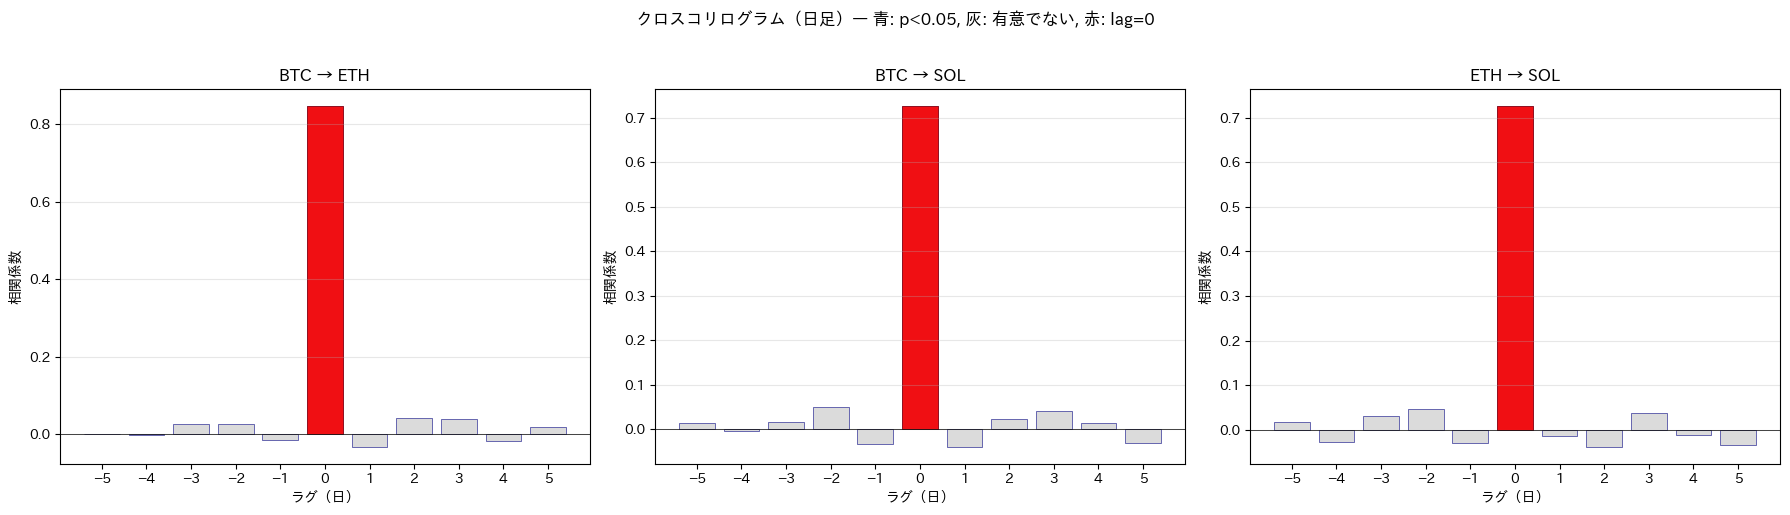

※ lag=0（赤）に圧倒的なピークがあり、ラグ≠0（灰色）はすべて有意でありません。
  これは「BTC→ETH」のような明確な先行・遅行関係が日足レベルでは存在しないことを示しています。


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ((sym1, sym2), res) in zip(axes, lag_results.items()):
    corrs = res["corrs"]
    pvals = res["pvals"]

    # 有意なラグ（p < 0.05）は青、そうでないものは灰色
    colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]
    ax.bar(lags, corrs, color=colors, edgecolor='navy', linewidth=0.5, alpha=0.8)

    # lag=0 を赤で強調
    idx_0 = lags.index(0)
    ax.bar(0, corrs[idx_0], color='red', edgecolor='darkred', linewidth=0.5, alpha=0.9)

    ax.set_xlabel("ラグ（日）")
    ax.set_ylabel("相関係数")
    ax.set_title(f"{sym1} → {sym2}")
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xticks(lags)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("クロスコリログラム（日足）— 青: p<0.05, 灰: 有意でない, 赤: lag=0",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("※ lag=0（赤）に圧倒的なピークがあり、ラグ≠0（灰色）はすべて有意でありません。")
print("  これは「BTC→ETH」のような明確な先行・遅行関係が日足レベルでは存在しないことを示しています。")

## 5. リードラグの安定性

全期間を通じてリードラグが見られなくても、**特定の期間だけ**に存在する可能性があります。
データを半年ごとのサブ期間に分割し、各期間でlag=+1の相関を計算します。

もし安定的にリードラグがあるなら、全サブ期間で同じ符号の相関が見られるはずです。

In [7]:
# 半年ごとにデータを分割してlag=+1相関を計算
boundaries = pd.date_range(start="2022-01-01", end="2025-01-01", freq="6MS", tz="UTC")

period_results = []
for i in range(len(boundaries) - 1):
    start = boundaries[i]
    end = boundaries[i + 1]
    label = f"{start.strftime('%Y-%m')}〜{end.strftime('%Y-%m')}"
    period_data = returns_1d[(returns_1d.index >= start) & (returns_1d.index < end)]

    if len(period_data) < 30:
        continue

    row = {"期間": label, "N": len(period_data)}
    for sym1, sym2 in pairs:
        valid = pd.DataFrame({
            "x": period_data[sym1].iloc[:-1].values,
            "y": period_data[sym2].iloc[1:].values,
        }).dropna()
        if len(valid) >= 20:
            r, p = stats.pearsonr(valid["x"], valid["y"])
            row[f"{sym1}→{sym2}"] = r
        else:
            row[f"{sym1}→{sym2}"] = np.nan
    period_results.append(row)

period_df = pd.DataFrame(period_results).set_index("期間")
print("=== 半年ごとの lag=+1 相関 ===\n")
display(period_df.round(4))

=== 半年ごとの lag=+1 相関 ===



,N,BTC→ETH,BTC→SOL,ETH→SOL
期間,,,,
2022-01〜2022-07,180,-0.0184,-0.0521,-0.0086
2022-07〜2023-01,184,-0.0532,0.0345,0.0497
2023-01〜2023-07,181,-0.0457,-0.0069,-0.0769
2023-07〜2024-01,184,-0.0980,-0.0890,0.0749
2024-01〜2024-07,182,-0.1330,-0.1932,-0.2011
2024-07〜2025-01,184,0.0657,-0.0268,-0.0148


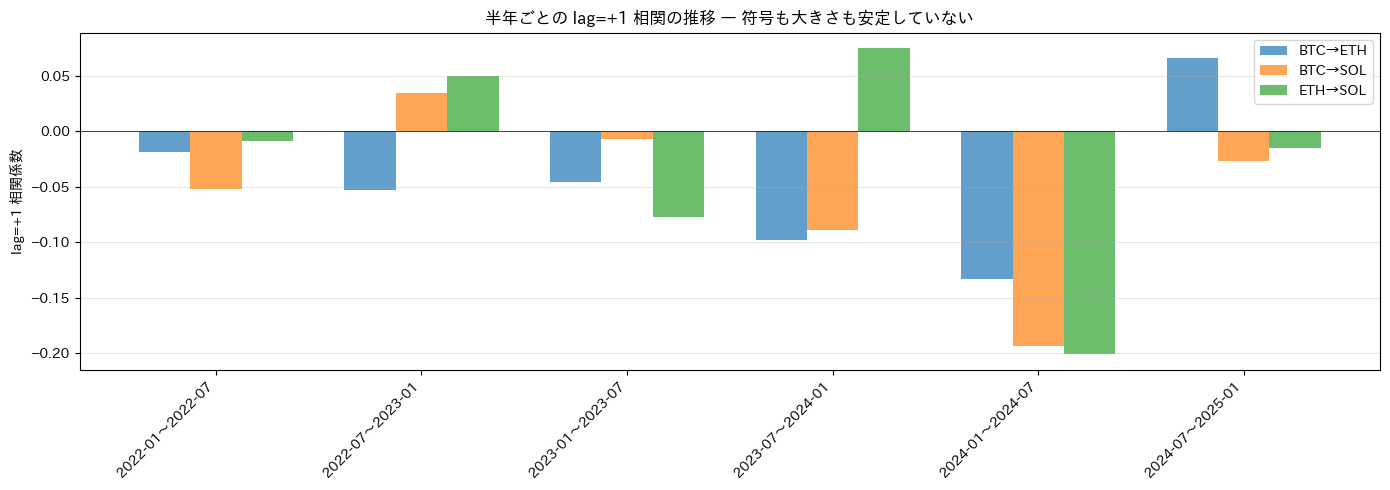

=== 安定性の定量評価 ===

BTC→ETH:
  平均: -0.0471, 標準偏差: 0.0686
  全期間で同じ符号: いいえ

BTC→SOL:
  平均: -0.0556, 標準偏差: 0.0792
  全期間で同じ符号: いいえ

ETH→SOL:
  平均: -0.0295, 標準偏差: 0.0995
  全期間で同じ符号: いいえ

→ lag=+1 の相関は期間ごとに符号が反転しており、安定したリードラグ関係は存在しません。


In [8]:
# 安定性の可視化
fig, ax = plt.subplots(figsize=(14, 5))

x = range(len(period_df))
width = 0.25
for j, col in enumerate(["BTC→ETH", "BTC→SOL", "ETH→SOL"]):
    offset = (j - 1) * width
    bars = ax.bar([xi + offset for xi in x], period_df[col], width, label=col, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(period_df.index, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel("lag=+1 相関係数")
ax.set_title("半年ごとの lag=+1 相関の推移 — 符号も大きさも安定していない")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 安定性の数値評価
print("=== 安定性の定量評価 ===\n")
for col in ["BTC→ETH", "BTC→SOL", "ETH→SOL"]:
    vals = period_df[col].dropna()
    same_sign = all(v > 0 for v in vals) or all(v < 0 for v in vals)
    print(f"{col}:")
    print(f"  平均: {vals.mean():+.4f}, 標準偏差: {vals.std():.4f}")
    print(f"  全期間で同じ符号: {'はい' if same_sign else 'いいえ'}")
    print()
print("→ lag=+1 の相関は期間ごとに符号が反転しており、安定したリードラグ関係は存在しません。")

## 6. リードラグを利用したトレーディングシミュレーション

リードラグが検出されない状況で、**それでも無理にシグナル化するとどうなるか**を確認します。

### 戦略のロジック

1. 前日のBTCリターンが閾値を超えたら、**翌日**にETH（またはSOL）にポジションを取る
2. BTC大幅上昇 → ETHをロング、BTC大幅下落 → ETHをショート
3. ポジションは1日で決済

### 閾値（しきい値）とは

閾値は「どの程度のBTCの変動をシグナルとみなすか」を決めるパラメータです。

| 閾値 | 意味 | トレード頻度 |
|------|------|-------------|
| 0.5% | BTCが±0.5%動いたらシグナル | 高い（ほぼ毎日） |
| 2.0% | BTCが±2.0%動いたらシグナル | 中程度 |
| 5.0% | BTCが±5.0%動いたらシグナル | 低い（月に数回） |

- **閾値が低い** → シグナル頻度が高い。ノイズを拾いやすいが、サンプル数が多く統計的に安定
- **閾値が高い** → 大きな動きだけを拾う。ノイズは少ないが、トレード回数が減り統計的に不安定

ここでは 0.5%〜5.0% の複数の閾値を試し、どれを選んでも結果が変わらないかを確認します。

### リークの回避

- シグナルは**前日のBTCリターン**（確定済み）に基づく
- トレードは**翌日のETH/SOLリターン**で評価
- 時刻 t のデータで時刻 t のトレードを行わない → リークなし

In [9]:
def simulate_lead_lag_strategy(returns_df, leader, follower, threshold_pct=1.0):
    """
    リードラグ戦略のシミュレーション（日足）。

    Parameters
    ----------
    returns_df : pd.DataFrame  リターンデータ
    leader : str  先行銘柄名（例: "BTC"）
    follower : str  追随銘柄名（例: "ETH"）
    threshold_pct : float  シグナル閾値（%表記、例: 1.0 = 1%）
    """
    threshold = threshold_pct / 100

    df = returns_df[[leader, follower]].copy()

    # シグナル: 先行銘柄のリターンが閾値を超えた場合
    df["signal"] = 0
    df.loc[df[leader] > threshold, "signal"] = 1    # ロング
    df.loc[df[leader] < -threshold, "signal"] = -1  # ショート

    # ポジション: シグナルを1日シフト（翌日に約定）
    df["position"] = df["signal"].shift(1).fillna(0).astype(int)

    # PnL: ポジション × 追随銘柄のリターン
    df["pnl"] = df["position"] * df[follower]
    df["cumulative_pnl"] = df["pnl"].cumsum()

    return df

# 複数の閾値でシミュレーション
thresholds = [0.5, 1.0, 2.0, 3.0, 5.0]

print("=== リードラグ戦略パフォーマンス（BTC → ETH）===")
rows = []
for th in thresholds:
    result = simulate_lead_lag_strategy(returns_1d, "BTC", "ETH", threshold_pct=th)
    trades = result[result["position"] != 0]
    n_trades = len(trades)
    if n_trades > 0:
        win_rate = (trades["pnl"] > 0).mean()
        mean_pnl = trades["pnl"].mean()
        cum_pnl = result["cumulative_pnl"].iloc[-1]
        sharpe = trades["pnl"].mean() / trades["pnl"].std() * np.sqrt(365) if trades["pnl"].std() > 0 else 0
    else:
        win_rate = mean_pnl = cum_pnl = sharpe = 0
    rows.append({
        "閾値(%)": th,
        "トレード数": n_trades,
        "勝率": f"{win_rate:.1%}",
        "平均PnL": mean_pnl,
        "累積PnL": cum_pnl,
        "Sharpe": sharpe,
    })

perf_df = pd.DataFrame(rows).set_index("閾値(%)")
display(perf_df.round(4))

=== リードラグ戦略パフォーマンス（BTC → ETH）===


,トレード数,勝率,平均PnL,累積PnL,Sharpe
閾値(%),,,,,
0.5,828,47.2%,-0.0007,-0.5709,-0.3461
1.0,640,46.7%,-0.0004,-0.2269,-0.1735
2.0,375,43.7%,-0.0019,-0.7311,-0.9231
3.0,230,42.6%,-0.0029,-0.6564,-1.3064
5.0,87,48.3%,-0.0010,-0.0863,-0.3899


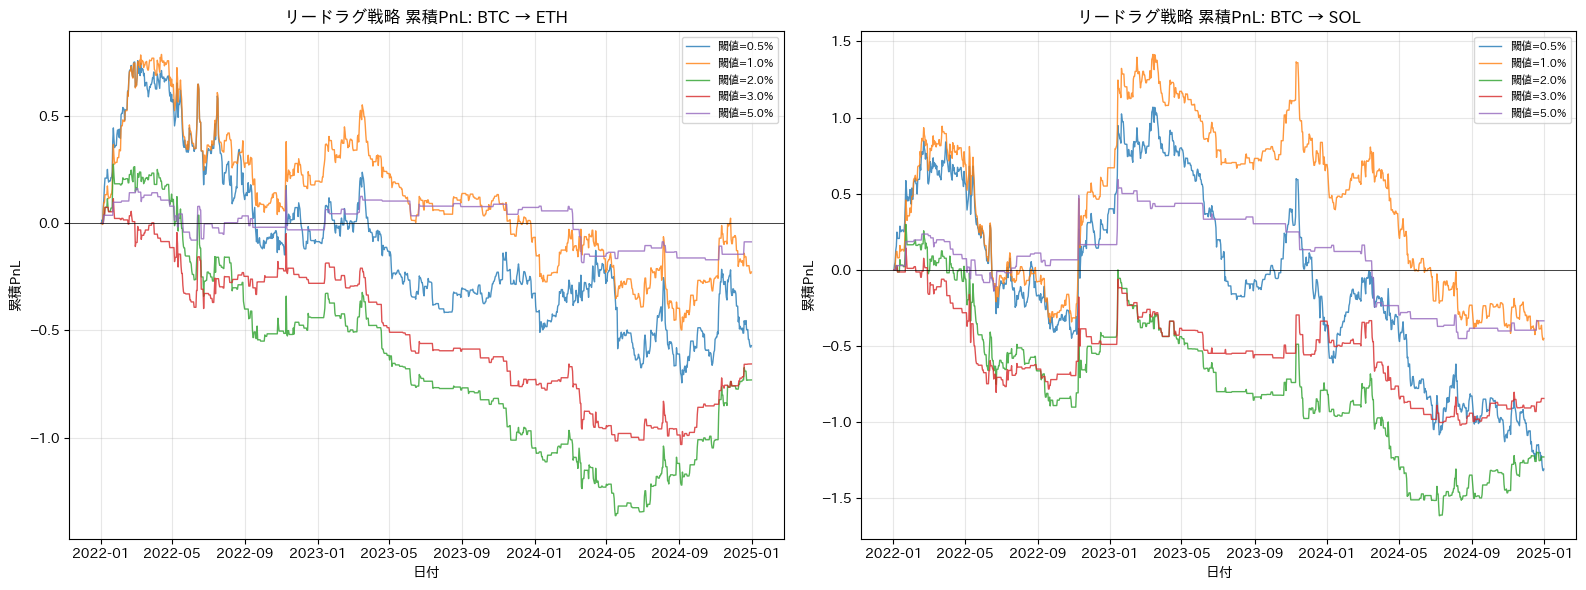

→ どの閾値を選んでも、累積PnLはゼロ付近をふらつくか、マイナスに沈んでいます。
  リードラグが存在しないため、シグナルに予測力がなく、取引コストを加味すれば確実に損失になります。


In [10]:
# 累積PnLのプロット（複数閾値の比較）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (leader, follower) in zip(axes, [("BTC", "ETH"), ("BTC", "SOL")]):
    for th in thresholds:
        result = simulate_lead_lag_strategy(returns_1d, leader, follower, threshold_pct=th)
        ax.plot(result.index, result["cumulative_pnl"],
                label=f"閾値={th:.1f}%", linewidth=1.0, alpha=0.8)
    ax.set_title(f"リードラグ戦略 累積PnL: {leader} → {follower}")
    ax.set_xlabel("日付")
    ax.set_ylabel("累積PnL")
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ どの閾値を選んでも、累積PnLはゼロ付近をふらつくか、マイナスに沈んでいます。")
print("  リードラグが存在しないため、シグナルに予測力がなく、取引コストを加味すれば確実に損失になります。")

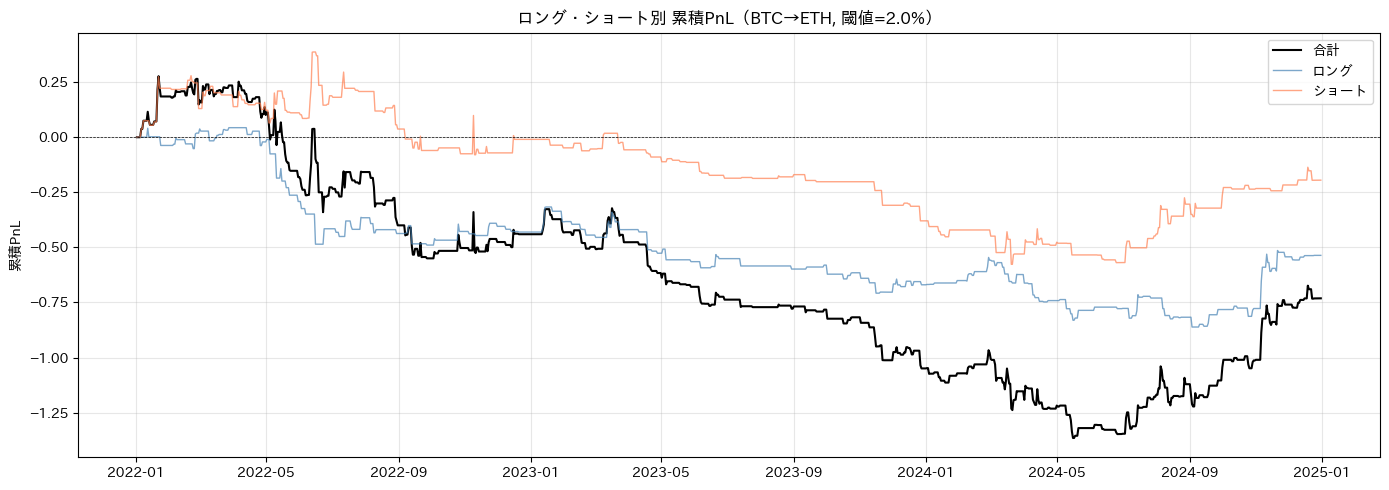

=== 閾値 2.0% の詳細分析（BTC → ETH）===
総トレード数: 375

--- ロング ---
  トレード数: 197
  勝率: 44.7%
  平均PnL: -0.002722

--- ショート ---
  トレード数: 178
  勝率: 42.7%
  平均PnL: -0.001095


In [11]:
# 代表的な閾値でのロング・ショート別PnL
best_threshold = 2.0
result = simulate_lead_lag_strategy(returns_1d, "BTC", "ETH", threshold_pct=best_threshold)

fig, ax = plt.subplots(figsize=(14, 5))

long_pnl = result["pnl"].where(result["position"] == 1, 0).cumsum()
short_pnl = result["pnl"].where(result["position"] == -1, 0).cumsum()
total_pnl = result["cumulative_pnl"]

ax.plot(result.index, total_pnl, label="合計", linewidth=1.5, color='black')
ax.plot(result.index, long_pnl, label="ロング", linewidth=1.0, color='steelblue', alpha=0.7)
ax.plot(result.index, short_pnl, label="ショート", linewidth=1.0, color='coral', alpha=0.7)

ax.set_title(f"ロング・ショート別 累積PnL（BTC→ETH, 閾値={best_threshold}%）")
ax.set_ylabel("累積PnL")
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# トレード統計
trades = result[result["position"] != 0]
print(f"=== 閾値 {best_threshold}% の詳細分析（BTC → ETH）===")
print(f"総トレード数: {len(trades):,}")
for direction, label in [(1, "ロング"), (-1, "ショート")]:
    dir_trades = trades[trades["position"] == direction]
    if len(dir_trades) > 0:
        print(f"\n--- {label} ---")
        print(f"  トレード数: {len(dir_trades):,}")
        print(f"  勝率: {(dir_trades['pnl'] > 0).mean():.1%}")
        print(f"  平均PnL: {dir_trades['pnl'].mean():.6f}")

## 7. データリークのチェック

### なぜリークチェックが必要なのか

バックテストにおける**データリーク**とは、トレード判断の時点ではまだ知り得ないはずの未来の情報を使ってしまうことです。リークがあると、バックテスト上では好成績に見えても、実運用では再現できません。

リークは**コードのバグ1つで簡単に発生**します。例えば:

- `shift(1)` を忘れてシグナルとポジションが同じ足になっている → シグナル生成に使った価格変動で利益を得ている（未来の情報を使用）
- 将来リターンを計算する際に `shift(-1)` の方向を間違える → 同上

特に厄介なのは、リークがあっても**コードはエラーなく動き、もっともらしい結果が出る**ことです。リークの存在に気づけるのは、データのタイミングを丁寧に検算した場合だけです。

### リークを疑うべきサイン

初心者がやりがちなミスとして、**リークに気づかないまま「すごいシグナルを見つけた」と思い込む**ケースがあります。

**もし価格リターンと異様に強い相関を持つ指標が見つかった場合、まずリークの可能性を疑ってください。** 金融市場で将来の価格変動と相関 0.3 を超える指標が見つかること自体が稀であり、相関 0.5 以上が出たらほぼ確実にどこかにリークがあると考えるべきです。

### チェック方法（タイミングの目視確認）

以下のコードでは、シグナルが発生した具体的な日付をピックアップし、**シグナル生成に使ったデータ**と**ポジションが反映される日**が正しく1日ずれていることを目視で確認します。

```
正しい流れ:
  t日: BTCリターン確定 → シグナル生成
  t+1日: ポジションに反映 → ETHリターンでPnLを計算
```

コード上は `df["position"] = df["signal"].shift(1)` の1行ですが、この shift が正しく効いているかを実データで検算することが重要です。

In [12]:
# リークチェック: シグナルとトレードのタイミングを確認
result_check = simulate_lead_lag_strategy(returns_1d, "BTC", "ETH", threshold_pct=2.0)
signal_rows = result_check[result_check["signal"] != 0]

print("=== データリークチェック ===\n")
print("シグナル発生時の前後のデータ（最初の5件）:\n")

for i, (idx, row) in enumerate(signal_rows.head(5).iterrows()):
    loc = result_check.index.get_loc(idx)
    if loc > 0 and loc < len(result_check) - 1:
        curr = result_check.iloc[loc]
        next_row = result_check.iloc[loc + 1]
        print(f"[{i+1}] {idx.date()}: BTC ret = {curr['BTC']:+.4f} → signal = {int(curr['signal']):+d}")
        print(f"    翌日 {result_check.index[loc+1].date()}: position = {int(next_row['position']):+d}, ETH ret = {next_row['ETH']:+.4f}, pnl = {next_row['pnl']:+.4f}")
        print()

print("✓ シグナルは当日のBTCリターン（確定済み）に基づき、ポジションは翌日に反映。リークなし。")

=== データリークチェック ===

シグナル発生時の前後のデータ（最初の5件）:

[1] 2022-01-05: BTC ret = -0.0519 → signal = -1
    翌日 2022-01-06: position = -1, ETH ret = -0.0378, pnl = +0.0378

[2] 2022-01-07: BTC ret = -0.0352 → signal = -1
    翌日 2022-01-08: position = -1, ETH ret = -0.0370, pnl = +0.0370

[3] 2022-01-11: BTC ret = +0.0217 → signal = +1
    翌日 2022-01-12: position = +1, ETH ret = +0.0406, pnl = +0.0406

[4] 2022-01-12: BTC ret = +0.0275 → signal = +1
    翌日 2022-01-13: position = +1, ETH ret = -0.0388, pnl = -0.0388

[5] 2022-01-13: BTC ret = -0.0306 → signal = -1
    翌日 2022-01-14: position = -1, ETH ret = +0.0206, pnl = -0.0206

✓ シグナルは当日のBTCリターン（確定済み）に基づき、ポジションは翌日に反映。リークなし。


### このチェックだけでは不十分

上のコードは「シグナル → ポジション」のタイミングのずれを確認するものですが、**これはリークチェックの一部にすぎません**。リークはデータパイプラインのあらゆる段階で発生しうるため、より広い観点でのチェックが必要です。

| チェック観点 | 具体例 | 見落としやすさ |
|-------------|--------|--------------|
| **データ取得時** | APIが返すタイムスタンプは足の開始時刻か終了時刻か？ 終了時刻のデータをその足の開始時点で使っていないか？ | 高い |
| **指標計算時** | 移動平均や標準偏差の計算に、全期間のデータ（未来を含む）を使っていないか？ `pd.qcut()` を全期間に適用すると、将来のデータで分位境界が決まりリークになる | 非常に高い |
| **データ結合時** | 異なるデータソース（価格、出来高、外部データ）を結合する際、タイムゾーンやデータの公開タイミングにずれはないか？ | 高い |
| **シグナル → ポジション** | `shift()` が正しく適用されているか？（本セクションで確認済み） | 中程度 |

実務では、**「このシグナルは本当にリアルタイムで計算可能か？」** という問いを、データの取得元まで遡って確認する習慣が不可欠です。

### 7.1 リークの例: shift を忘れるとどうなるか

ここで、リークがどれほど結果を歪めるかを実際に体験してみましょう。

セクション6の戦略では、**前日の**BTCリターンでシグナルを出し、**翌日の**ETHリターンでPnLを計算しました（`shift(1)` によるリーク防止）。

では、`shift(1)` を忘れて **当日の** BTCリターンでシグナルを出し、**同じ当日の** ETHリターンでPnLを計算してしまったらどうなるでしょうか？

BTC と ETH は Vol.03 で確認したとおり同時相関が 0.85 もあるため、「BTCが上がった日にETHをロングする」戦略は**当然のように利益が出ます**。しかしこれは「BTCが上がったことを確認してから、同じ日のETHの上昇で利益を得る」という、**時間的に不可能なトレード**です。

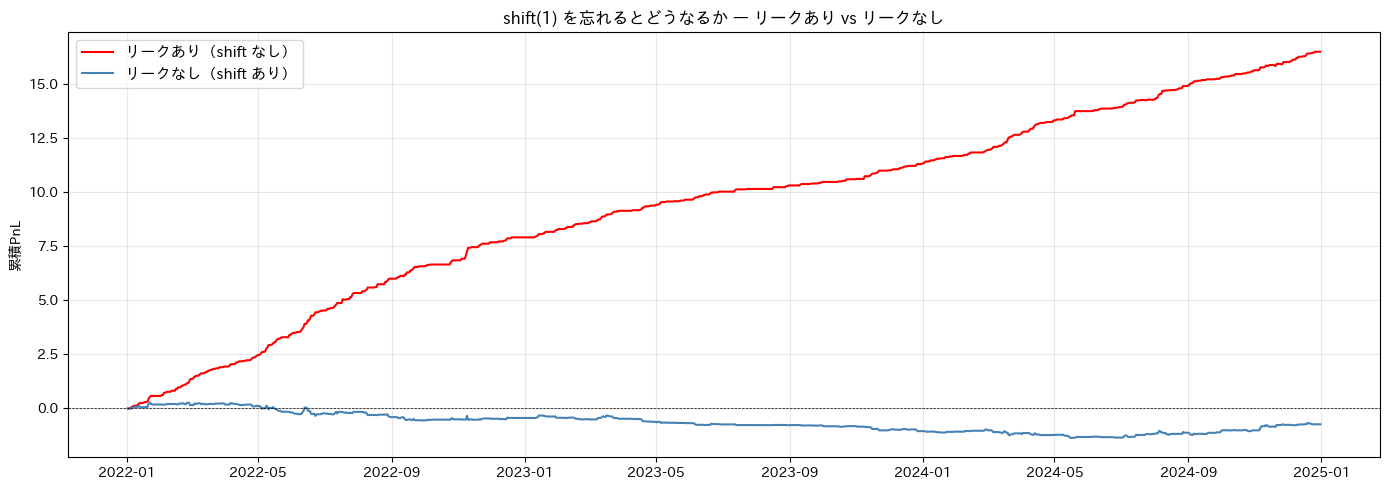

リークあり: 累積PnL = +16.5147, Sharpe = 25.74（トレード 375 回）
リークなし: 累積PnL = -0.7311, Sharpe = -0.92（トレード 375 回）

→ shift(1) を1つ忘れるだけで、存在しないはずのエッジが出現します。
  バックテストで「良すぎる結果」が出たら、まずリークを疑いましょう。


In [13]:
# --- リークの例: shift(1) を忘れた場合 ---
# 「当日のBTCリターン → 当日のETHポジション」という、実行不可能な戦略

df_leak = returns_1d[["BTC", "ETH"]].copy()

# ★ リークあり: shift なし（当日のBTCで当日のETHをトレード）
threshold = 0.02
df_leak["signal_leak"] = 0
df_leak.loc[df_leak["BTC"] > threshold, "signal_leak"] = 1
df_leak.loc[df_leak["BTC"] < -threshold, "signal_leak"] = -1
df_leak["position_leak"] = df_leak["signal_leak"]  # shift なし！
df_leak["pnl_leak"] = df_leak["position_leak"] * df_leak["ETH"]

# ★ リークなし: shift(1) あり（前日のBTCで翌日のETHをトレード）
df_leak["signal_correct"] = df_leak["signal_leak"]
df_leak["position_correct"] = df_leak["signal_correct"].shift(1).fillna(0).astype(int)
df_leak["pnl_correct"] = df_leak["position_correct"] * df_leak["ETH"]

# プロット比較
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_leak.index, df_leak["pnl_leak"].cumsum(),
        label="リークあり（shift なし）", color="red", linewidth=1.5)
ax.plot(df_leak.index, df_leak["pnl_correct"].cumsum(),
        label="リークなし（shift あり）", color="steelblue", linewidth=1.5)
ax.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("shift(1) を忘れるとどうなるか — リークあり vs リークなし")
ax.set_ylabel("累積PnL")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 数値比較（ポジション保有中のPnLのみで算出 — Cell 15と同じ基準）
for label, pos_col, pnl_col in [
    ("リークあり", "position_leak", "pnl_leak"),
    ("リークなし", "position_correct", "pnl_correct"),
]:
    trades = df_leak[df_leak[pos_col] != 0][pnl_col]
    cum = df_leak[pnl_col].cumsum().iloc[-1]
    sharpe = trades.mean() / trades.std() * np.sqrt(365) if len(trades) > 0 and trades.std() > 0 else 0
    print(f"{label}: 累積PnL = {cum:+.4f}, Sharpe = {sharpe:.2f}（トレード {len(trades)} 回）")

print()
print("→ shift(1) を1つ忘れるだけで、存在しないはずのエッジが出現します。")
print("  バックテストで「良すぎる結果」が出たら、まずリークを疑いましょう。")

## 8. 取引コストの影響

リードラグが存在しない（エッジがゼロに近い）状況では、取引コストが致命的になります。
コスト込みの累積PnLを確認し、「エッジがない戦略にコストが加わるとどうなるか」を体感します。

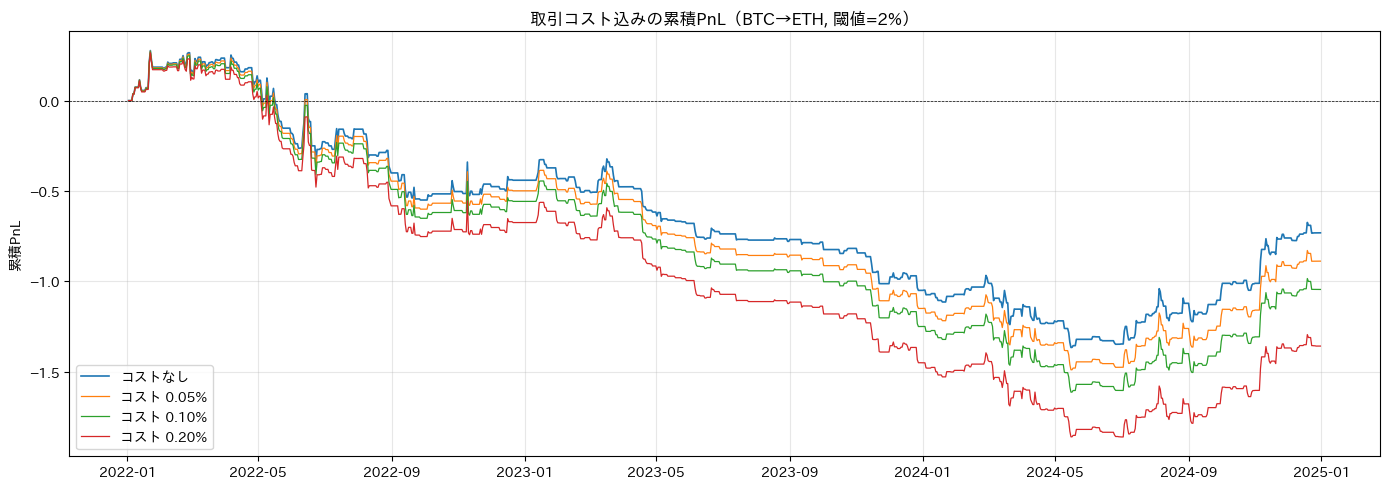

→ コストなしでもほぼゼロの累積PnLが、コストを加えると確実にマイナスへ。
  エッジのない戦略は、取引するだけでコスト分だけ損失を積み上げます。


In [14]:
# 取引コストの影響を可視化
cost_levels = [0, 0.0005, 0.001, 0.002]  # 0%, 0.05%, 0.1%, 0.2%（往復）

fig, ax = plt.subplots(figsize=(14, 5))

result = simulate_lead_lag_strategy(returns_1d, "BTC", "ETH", threshold_pct=2.0)

for cost in cost_levels:
    pnl_with_cost = result["pnl"].copy()
    # ポジションが変わった足にコストを適用
    position_changed = result["position"] != result["position"].shift(1)
    pnl_with_cost[position_changed & (result["position"] != 0)] -= cost
    cum_pnl = pnl_with_cost.cumsum()
    label = f"コスト {cost*100:.2f}%" if cost > 0 else "コストなし"
    ax.plot(result.index, cum_pnl, label=label, linewidth=1.2 if cost == 0 else 0.9)

ax.set_title("取引コスト込みの累積PnL（BTC→ETH, 閾値=2%）")
ax.set_ylabel("累積PnL")
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ コストなしでもほぼゼロの累積PnLが、コストを加えると確実にマイナスへ。")
print("  エッジのない戦略は、取引するだけでコスト分だけ損失を積み上げます。")

## 9. まとめ

このnotebookでは、BTC・ETH・SOL間の**リードラグ分析**を日足データで行いました。

### 学んだこと

| テーマ | 内容 | ポイント |
|--------|------|---------|
| ラグ付き相関 | 時間をずらして相関を計算する手法 | lag=0 がピーク → リードラグなし |
| クロスコリログラム | ラグ相関をバーチャートで可視化 | 視覚的に先行・遅行関係を判断 |
| 安定性検証 | 半年ごとの分割で一貫性を確認 | 期間ごとに符号が反転 → 不安定 |
| トレーディングシミュレーション | リードラグ戦略の累積PnL | エッジがなく、コスト負け |
| データリーク | リアルタイムで知り得ない情報の混入 | 強すぎる相関はまずリークを疑う |

### このnotebookの最も重要な教訓

**主要暗号資産間のリードラグは、日足レベルではほぼ検出されません。**

これは暗号資産市場の効率性が高いことを意味しています。BTC・ETH・SOLのような主要銘柄は情報の反映が速く、「BTCの動きを見てからETHを買う」といった素朴な戦略ではエッジを得られません。

### 「見つからない」ことの価値

データ分析では、**仮説が棄却されること自体に大きな価値があります**。

- 「リードラグがある」という思い込みで戦略を構築し、実運用で損失を出す — これを避けられた
- 「この方向にはエッジがない」と分かれば、別の仮説（出来高、オーダーフロー、取引所間裁定など）に時間を集中できる
- **根拠のない戦略に資金を投じないこと**は、利益を出すことと同じくらい重要

### データリークへの警戒

リークチェックはバックテストの信頼性を保つための最も基本的な作業です。

- 将来リターンと相関 0.3 を超える指標が見つかったら、まずリークを疑う
- `shift()` のタイミング確認だけでなく、データ取得・指標計算・データ結合の各段階で「この情報はリアルタイムで知り得たか？」を検証する
- リークのあるバックテストはどんなに好成績でも無価値

### 次のステップ

Vol.05 では、テクニカル指標（RSI、移動平均など）を使って、**価格の内部構造**から将来リターンを予測できる指標を探索します。銘柄間の先行・遅行ではなく、**1つの銘柄の過去の情報**から予測する方向へ進みます。

## 分析結果から分かったこと

### リードラグの不在
- BTC・ETH・SOL間の日足ラグ相関は、全ペア・全ラグで ±0.04 以内（ほぼゼロ）
- 全ペアで lag=0 がピークであり、価格変動はほぼ同時に起きている
- 半年ごとの分割では lag=+1 の符号すら安定しておらず、一時的なリードラグ関係も見られなかった

### トレーディングへの含意
- リードラグに基づくシンプルな戦略（BTC急変 → 翌日ETHポジション）は、全閾値で累積PnLがほぼゼロ
- 取引コストを加味すると確実にマイナス
- **主要暗号資産間の日足リードラグには、収益化可能なエッジは存在しない**

### 市場の効率性
- BTC・ETH・SOLは世界中で24時間取引されており、情報の反映が非常に速い
- 1日という時間スケールでは、銘柄間の情報伝搬はすでに完了している
- より短い時間スケール（数秒〜数分）ではリードラグが存在する可能性があるが、それは高頻度取引の領域であり、低遅延のインフラと高度な執行技術が必要になる

### データリークの重要性
- 価格に先行する指標を見つけることは非常に難しい。だからこそ、「見つかった」と思ったときは真っ先にリークを疑うべき
- リークチェックはシグナル→ポジションのタイミングだけでなく、データ取得・指標計算・データ結合の全段階で必要